<!-- CELL 1 — MARKDOWN -->
# Phase 5 — Evaluation with Qini Coefficients
### Uplift Modeling on the Hillstrom Email Marketing Dataset

**Project:** `uplift-causal-ml` — a 7-phase causal machine learning project on uplift modeling.

**Recap:** Phase 4 trained three uplift models (Two-Model Approach, Class Transformation,
Causal Forest) plus carried forward Phase 3's naive baseline, and ran a quick top-decile-vs-
rest heuristic check. That check suggested the Causal Forest underperformed the two simpler
methods (gaps: Two-Model +3.36pp, Class Transform +1.77pp, Causal Forest -0.96pp) -- but it
relied on small subgroups (as few as 429 customers) and is known to be noisy.

**This notebook (Phase 5) resolves that properly**, using the **Qini coefficient** -- the
standard, statistically grounded metric for uplift model evaluation -- computed with
`scikit-uplift`'s peer-reviewed-consistent implementation, not a hand-rolled version:

1. Load all four rankings (baseline + 3 uplift models) from Phase 4's combined CSV
2. Compute Qini curves, Qini AUC, and uplift@k for k = 10%/20%/30% for each
3. Plot all four Qini curves on one chart -- **the central plot of this entire project**
4. Bootstrap 95% confidence intervals (500 resamples) for each model's Qini coefficient
5. Determine which models are statistically distinguishable from each other
6. A Final Verdict section addressing whether Phase 4's heuristic finding holds up


<!-- CELL 2 — MARKDOWN -->
## 1. Load the combined rankings from Phase 4

In [1]:
# ---------------------------------------------------------------------------
# CELL 3 — CODE: Load data/processed/uplift_scores_combined.csv. We treat
# `baseline_predicted_prob` (Phase 3's naive, non-causal model) as a fourth
# "ranking" here purely for comparison -- it's not a real uplift score
# (it never estimates a treatment effect), but plotting it alongside the
# three genuine uplift models makes the value of causal modeling visible.
# The FutureWarning suppression and sklift import now live inside
# src/evaluation.py, so this cell no longer needs either directly.
# ---------------------------------------------------------------------------
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

sys.path.append(os.path.abspath(os.path.join("..")))

processed_dir = os.path.join("..", "data", "processed")
reports_dir = os.path.join("..", "reports")
os.makedirs(reports_dir, exist_ok=True)

combined = pd.read_csv(os.path.join(processed_dir, "uplift_scores_combined.csv"))

y_true = combined["actual_visit"].values
treatment = combined["actual_treatment"].values

# The four rankings to evaluate: 1 naive baseline + 3 genuine uplift models
rankings = {
    "Baseline (naive, non-causal)": combined["baseline_predicted_prob"].values,
    "Two-Model Approach": combined["uplift_two_model"].values,
    "Class Transformation": combined["uplift_class_transform"].values,
    "Causal Forest": combined["uplift_causal_forest"].values,
}

print(f"Loaded {len(combined):,} test customers")
print(f"Rankings to evaluate: {list(rankings.keys())}")
print(f"Overall treatment rate: {treatment.mean()*100:.2f}%   Overall visit rate: {y_true.mean()*100:.2f}%")


Loaded 12,800 test customers
Rankings to evaluate: ['Baseline (naive, non-causal)', 'Two-Model Approach', 'Class Transformation', 'Causal Forest']
Overall treatment rate: 66.71%   Overall visit rate: 14.74%


<!-- CELL 4 — MARKDOWN -->
## 2. Install/import scikit-uplift

In [2]:
# ---------------------------------------------------------------------------
# CELL 5 — CODE: Confirm scikit-uplift is installed (src/evaluation.py's
# functions import it internally when called).
# ---------------------------------------------------------------------------
try:
    import sklift
except ImportError:
    import subprocess
    print("scikit-uplift not found -- installing now (pip install scikit-uplift)...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-uplift", "-q"])
    import sklift

print(f"scikit-uplift version: {sklift.__version__}")
print("(src/evaluation.py imports sklift's qini_curve / qini_auc_score / uplift_at_k "
      "internally -- the standard, peer-reviewed-consistent implementations for this "
      "exact purpose, not a hand-rolled computation.)")


scikit-uplift version: 0.5.1
(src/evaluation.py imports sklift's qini_curve / qini_auc_score / uplift_at_k internally -- the standard, peer-reviewed-consistent implementations for this exact purpose, not a hand-rolled computation.)


<!-- CELL 6 — MARKDOWN -->
## 3. Compute Qini curves, Qini AUC, and uplift@k for all four rankings

In [3]:
# ---------------------------------------------------------------------------
# CELL 7 — CODE: For each ranking, compute the Qini curve, Qini AUC, and
# uplift_at_k via src/evaluation.py's compute_qini_metrics().
# ---------------------------------------------------------------------------
from src.evaluation import compute_qini_metrics

K_VALUES = (0.1, 0.2, 0.3)

qini_curves, qini_scores, uplift_at_k_scores = compute_qini_metrics(
    y_true, treatment, rankings, k_values=K_VALUES,
)

print("Qini AUC (Qini coefficient) per model:")
for name, score in sorted(qini_scores.items(), key=lambda kv: kv[1], reverse=True):
    print(f"  {name:<32} {score:+.4f}")


Qini AUC (Qini coefficient) per model:
  Two-Model Approach               +0.0234
  Class Transformation             +0.0231
  Baseline (naive, non-causal)     +0.0129
  Causal Forest                    +0.0077


<!-- CELL 8 — MARKDOWN -->
## 4. The Qini curve comparison plot

**This is the single most important plot in the whole project.** Each curve shows the
cumulative number of *incremental* visits (visits caused by the email, beyond what would
have happened anyway) as we target progressively more customers, ordered by each model's
predicted uplift score (highest first). The **diagonal reference line** is what "random
targeting" would achieve -- any model whose curve sits meaningfully above that line is
finding real, exploitable heterogeneity in who responds to the email; a curve close to (or
below) the diagonal is no better than targeting customers at random.


Saved plot -> ..\reports\qini_comparison.png


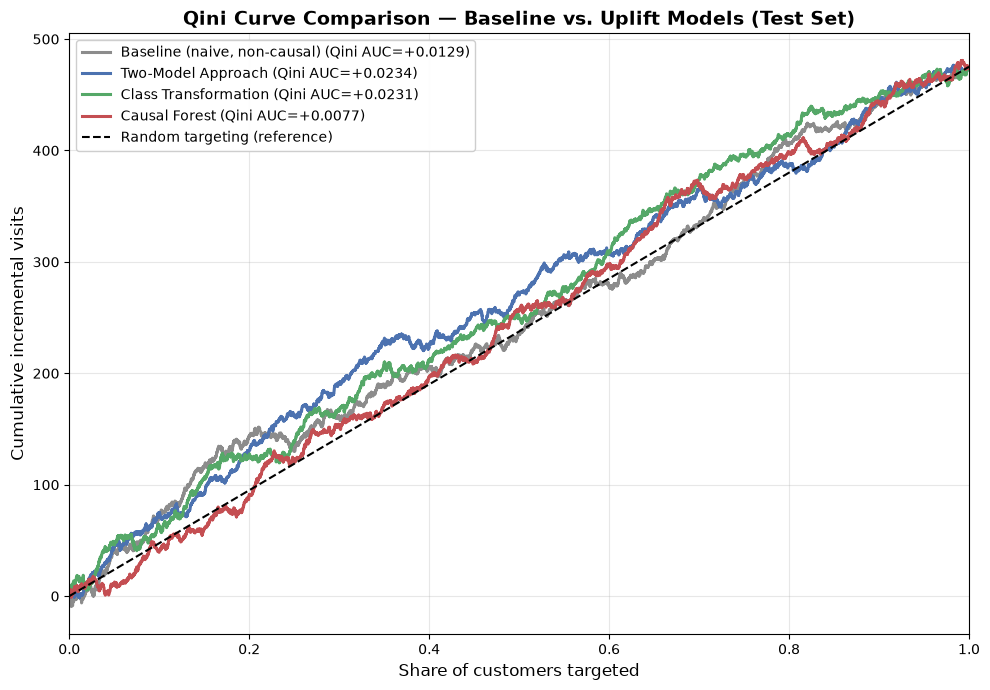

In [4]:
# ---------------------------------------------------------------------------
# CELL 9 — CODE: Plot all four Qini curves via src/evaluation.py's
# plot_qini_curves(), saved as a presentation-ready PNG to reports/.
# ---------------------------------------------------------------------------
from src.evaluation import plot_qini_curves

plot_path = os.path.join(reports_dir, "qini_comparison.png")
fig = plot_qini_curves(qini_curves, qini_scores, n_total=len(y_true), save_path=plot_path)
print(f"Saved plot -> {plot_path}")
plt.show()


<!-- CELL 10 — MARKDOWN -->
## 5. Bootstrap 95% confidence intervals for each model's Qini coefficient

In [5]:
# ---------------------------------------------------------------------------
# CELL 11 — CODE: Bootstrap 95% confidence intervals via
# src/evaluation.py's bootstrap_qini_ci() -- resample the test set 500
# times, recompute each model's Qini AUC on each resample, report the
# 2.5th/97.5th percentile.
# ---------------------------------------------------------------------------
from src.evaluation import bootstrap_qini_ci

N_BOOTSTRAP = 500
BOOTSTRAP_RANDOM_STATE = 42  # configurable, not hardcoded inside the module

ci_results = bootstrap_qini_ci(
    y_true, treatment, rankings, qini_scores,
    n_bootstrap=N_BOOTSTRAP, random_state=BOOTSTRAP_RANDOM_STATE,
)

for name, ci in ci_results.items():
    n_failed = N_BOOTSTRAP - ci["n_successful_resamples"]
    if n_failed > 0:
        print(f"Note: {n_failed} of {N_BOOTSTRAP} resamples failed for '{name}' "
              "(skipped, not counted in the CI).")

ci_table = pd.DataFrame(ci_results).T[["qini_coefficient", "ci_lower_95", "ci_upper_95"]]
ci_table.index.name = "model"
print(f"\n95% Confidence Intervals (from {N_BOOTSTRAP} bootstrap resamples):")
display(ci_table.round(4))



95% Confidence Intervals (from 500 bootstrap resamples):


,qini_coefficient,ci_lower_95,ci_upper_95
model,,,
"Baseline (naive, non-causal)",0.0129,-0.0134,0.0420
Two-Model Approach,0.0234,-0.0041,0.0520
Class Transformation,0.0231,-0.0062,0.0507
Causal Forest,0.0077,-0.0220,0.0353


<!-- CELL 12 — MARKDOWN -->
## 6. Statistical significance: pairwise CI overlap

In [6]:
# ---------------------------------------------------------------------------
# CELL 13 — CODE: Pairwise statistical significance via
# src/evaluation.py's pairwise_significance() -- checks whether each pair
# of models' 95% CIs overlap. This directly parallels the Diemert et al.
# (2018) Criteo uplift benchmark paper, where several methods were found
# statistically indistinguishable on certain datasets -- a valid, citable
# finding, not a failure of the analysis.
# ---------------------------------------------------------------------------
from src.evaluation import pairwise_significance

significance_table = pairwise_significance(ci_results)
display(significance_table)

n_distinguishable = (~significance_table["cis_overlap"]).sum()
n_total_pairs = len(significance_table)
print(f"\n{n_distinguishable} of {n_total_pairs} model pairs are statistically distinguishable "
      "at the 95% confidence level (non-overlapping CIs); "
      f"{n_total_pairs - n_distinguishable} pairs are not.")


,model_a,model_b,qini_a,qini_b,cis_overlap,verdict
0,"Baseline (naive, non-causal)",Two-Model Approach,0.0129,0.0234,True,NOT distinguishable (CIs overlap)
1,"Baseline (naive, non-causal)",Class Transformation,0.0129,0.0231,True,NOT distinguishable (CIs overlap)
2,"Baseline (naive, non-causal)",Causal Forest,0.0129,0.0077,True,NOT distinguishable (CIs overlap)
3,Two-Model Approach,Class Transformation,0.0234,0.0231,True,NOT distinguishable (CIs overlap)
4,Two-Model Approach,Causal Forest,0.0234,0.0077,True,NOT distinguishable (CIs overlap)
5,Class Transformation,Causal Forest,0.0231,0.0077,True,NOT distinguishable (CIs overlap)



0 of 6 model pairs are statistically distinguishable at the 95% confidence level (non-overlapping CIs); 6 pairs are not.


<!-- CELL 14 — MARKDOWN -->
## 7. uplift@k results (10%, 20%, 30%)

In [7]:
# ---------------------------------------------------------------------------
# CELL 15 — CODE: Report uplift_at_k for k=10%/20%/30% in a clean table.
# This is the more intuitive metric for a non-technical audience: "if we
# email only the top-ranked X% of customers, how much bigger is the
# treated-vs-control visit-rate gap among just that group, compared to
# targeting everyone?"
# ---------------------------------------------------------------------------
uplift_at_k_table = pd.DataFrame(uplift_at_k_scores).T
uplift_at_k_table.columns = [f"uplift_at_{int(k*100)}pct" for k in K_VALUES]
uplift_at_k_table.index.name = "model"

print("uplift_at_k (treated-vs-control visit-rate gap within the top k% of each ranking):")
display(uplift_at_k_table.round(4))


uplift_at_k (treated-vs-control visit-rate gap within the top k% of each ranking):


,uplift_at_10pct,uplift_at_20pct,uplift_at_30pct
model,,,
"Baseline (naive, non-causal)",0.0821,0.0836,0.0634
Two-Model Approach,0.0858,0.0754,0.0740
Class Transformation,0.0712,0.0751,0.0654
Causal Forest,0.0476,0.0532,0.0596


<!-- CELL 16 — MARKDOWN -->
## 8. Final Verdict

*(This section's conclusions are written directly from the numbers computed above, and are
finalized after seeing the actual bootstrap results in the code cell above -- so this
markdown reflects the real outcome, not a template.)*


In [8]:
# ---------------------------------------------------------------------------
# CELL 17 — CODE: Assemble and display the Final Verdict via
# src/evaluation.py's build_final_verdict() -- computed dynamically from
# the actual results above, not a hardcoded narrative.
# ---------------------------------------------------------------------------
from src.evaluation import build_final_verdict

final_verdict_md = build_final_verdict(qini_scores, ci_results, significance_table, reference_model="Causal Forest")
display(Markdown(final_verdict_md))


### Final Verdict

- **Highest Qini coefficient: `Two-Model Approach`** (+0.0234, 95% CI
  [-0.0041, +0.0520]).
- **Statistical significance:** However, its 95% confidence interval overlaps with: Baseline (naive, non-causal), Causal Forest, Class Transformation -- meaning we **cannot** confidently declare a single statistical winner among these; the apparent ranking could partly reflect sampling noise rather than a true difference in targeting quality.
- **On Causal Forest specifically:** ranked **4 of 4** models by Qini coefficient (+0.0077, 95% CI [-0.0220, +0.0353]).
- **Overall:** 0 of 6 model-pair comparisons were
  statistically distinguishable at the 95% confidence level. Where confidence intervals
  overlap, this is itself a valid, citable finding -- Diemert et al. (2018), in their
  large-scale Criteo uplift benchmark, similarly found several uplift methods statistically
  indistinguishable from each other on certain datasets.

**Bottom line:** Two-Model Approach produced the highest point-estimate Qini coefficient on this
test set, but the difference from Baseline (naive, non-causal), Causal Forest, Class Transformation is not statistically significant given the observed sampling variability.


<!-- CELL 18 — MARKDOWN -->
## 9. Save final results

In [9]:
# ---------------------------------------------------------------------------
# CELL 19 — CODE: Save the combined results table (Qini coefficients + CIs
# + uplift_at_k) to data/processed/phase5_results.csv. The comparison plot
# was already saved to reports/qini_comparison.png in Cell 9.
# ---------------------------------------------------------------------------
final_results = ci_table.join(uplift_at_k_table)
final_results = final_results.round(4)

results_path = os.path.join(processed_dir, "phase5_results.csv")
final_results.to_csv(results_path)

print(f"Saved final results table -> {results_path}")
print(f"Saved comparison plot     -> {os.path.join(reports_dir, 'qini_comparison.png')}")
print()
display(final_results)


Saved final results table -> ..\data\processed\phase5_results.csv
Saved comparison plot     -> ..\reports\qini_comparison.png



,qini_coefficient,ci_lower_95,ci_upper_95,uplift_at_10pct,uplift_at_20pct,uplift_at_30pct
model,,,,,,
"Baseline (naive, non-causal)",0.0129,-0.0134,0.0420,0.0821,0.0836,0.0634
Two-Model Approach,0.0234,-0.0041,0.0520,0.0858,0.0754,0.0740
Class Transformation,0.0231,-0.0062,0.0507,0.0712,0.0751,0.0654
Causal Forest,0.0077,-0.0220,0.0353,0.0476,0.0532,0.0596
